# COCO Format Previwer

 This one is a notebook to preview converted dataset from what they were to COCO format

### BUU AP Dataset

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pycocotools.coco import COCO

In [3]:
coco = COCO("/Users/gcpuppy/Documents/WorkSpaces/Spine-Opportunistic-Screening/dataset/BUU AP/_annotations.keypoints.coco.json")

loading annotations into memory...


FileNotFoundError: [Errno 2] No such file or directory: '/Users/gcpuppy/Documents/WorkSpaces/Spine-Opportunistic-Screening/dataset/BUU AP/_annotations.keypoints.coco.json'

In [3]:
img_ids = coco.getImgIds()
img = coco.loadImgs(img_ids[0])[0]

ann_ids = coco.getAnnIds(imgIds=[img["id"]])
anns = coco.loadAnns(ann_ids)

print(img)
print(anns[0])

{'id': 1, 'file_name': 'BUU-AP-00001.jpg', 'width': 1823, 'height': 2147}
{'id': 1, 'image_id': 1, 'category_id': 1, 'bbox': [865.994, 167.062, 254.002, 146.605], 'area': 35655.68, 'iscrowd': 0, 'num_keypoints': 4, 'keypoints': [876.222, 167.062, 2, 1111.472, 168.767, 2, 865.994, 313.667, 2, 1119.996, 313.667, 2], 'segmentation': [[876.2222, 167.0618, 1111.472, 168.7665, 1119.996, 313.6671, 865.9939, 313.6671]], 'vertebra_index': 1}


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


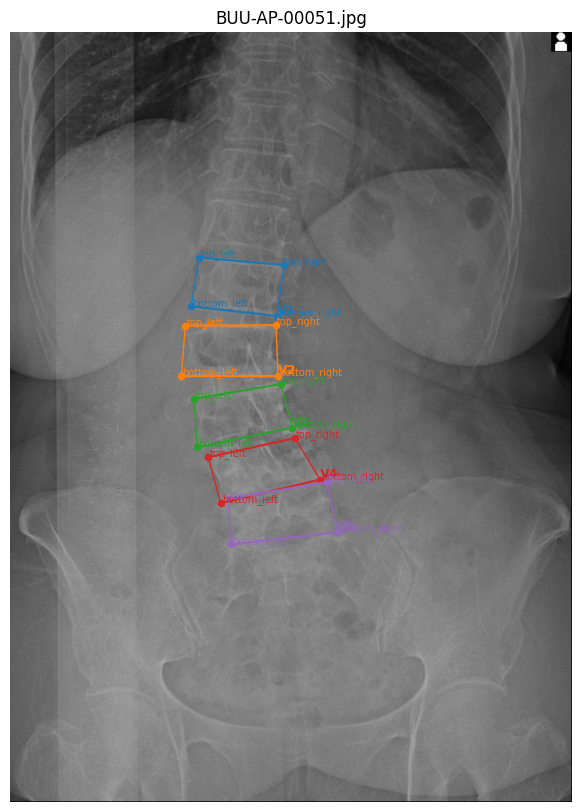

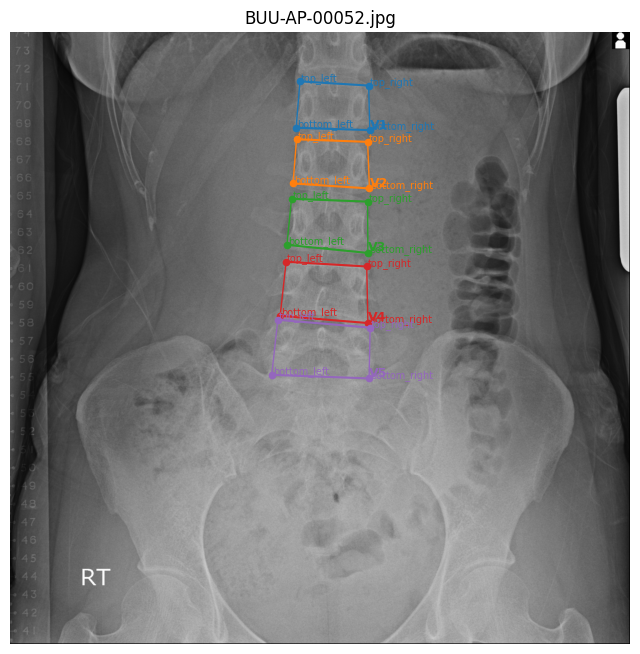

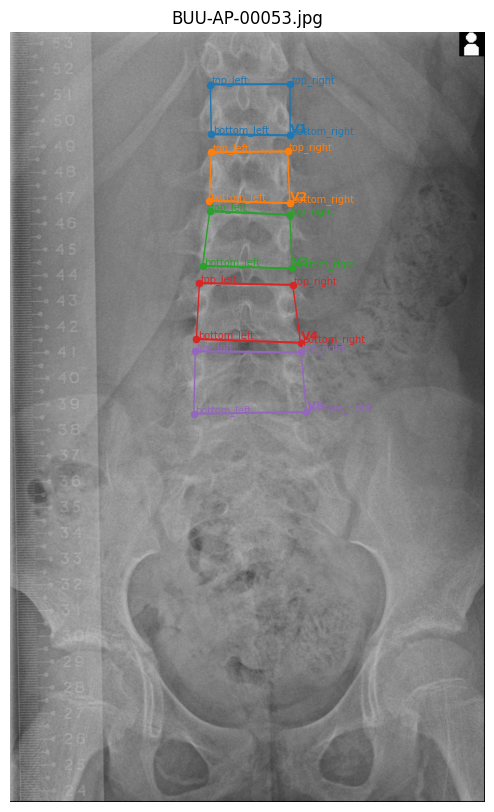

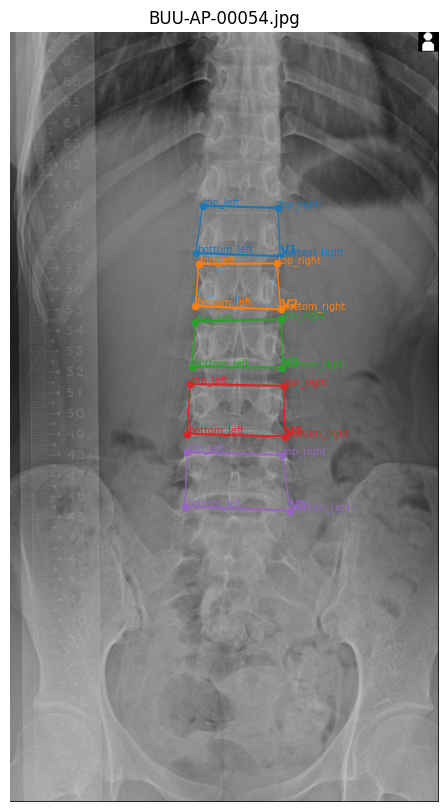

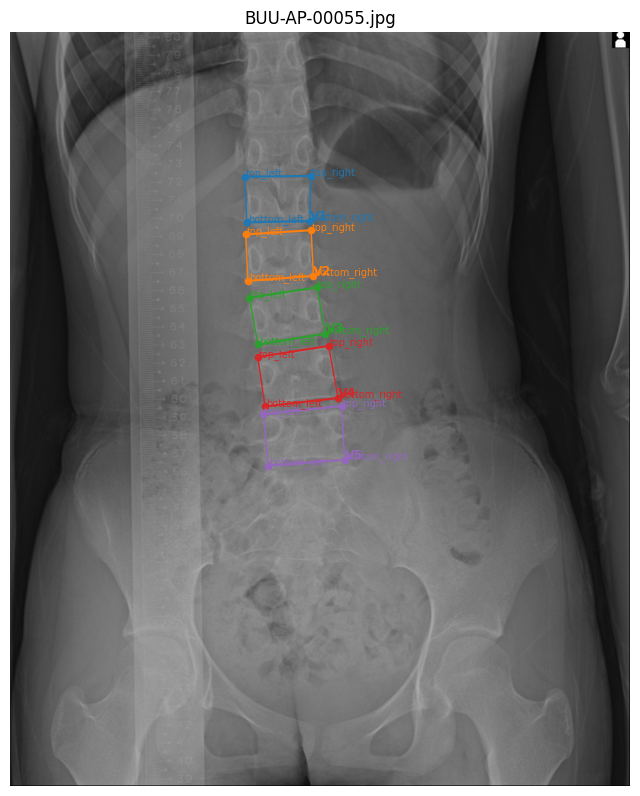

In [4]:
json_path = Path("/Users/gcpuppy/Documents/WorkSpaces/Spine-Opportunistic-Screening/dataset/BUU AP/_annotations.keypoints.coco.json")
image_dir = json_path.parent

coco = COCO(str(json_path))

images = sorted(coco.dataset["images"], key=lambda x: x["id"])

cat = coco.loadCats(coco.getCatIds())[0]
kp_names = cat["keypoints"]

batch_num = 10
batch_size = 5

start = batch_num * batch_size
end = min((batch_num + 1) * batch_size, len(images))

for i in range(start, end):
    img_info = images[i]
    img_path = image_dir / img_info["file_name"]
    img = plt.imread(img_path)

    ann_ids = coco.getAnnIds(imgIds=[img_info["id"]])
    annotations = coco.loadAnns(ann_ids)
    annotations = sorted(annotations, key=lambda a: a.get("vertebra_index", 999))

    plt.figure(figsize=(8, 10))
    plt.imshow(img, cmap="gray")
    ax = plt.gca()

    for ann in annotations:
        color = plt.cm.tab10((ann["vertebra_index"] - 1) % 10)

        # keypoints: [x, y, v, x, y, v, ...] -> reshape เป็น (4, 3)
        kpts = np.array(ann["keypoints"]).reshape(-1, 3)

        # จุด: 0=top_left, 1=top_right, 2=bottom_left, 3=bottom_right
        tl, tr, bl, br = kpts

        if tl[2] > 0 and tr[2] > 0:
            plt.plot([tl[0], tr[0]], [tl[1], tr[1]], color=color, linewidth=1.5)
        if bl[2] > 0 and br[2] > 0:
            plt.plot([bl[0], br[0]], [bl[1], br[1]], color=color, linewidth=1.5)

        if tl[2] > 0 and bl[2] > 0:
            plt.plot([tl[0], bl[0]], [tl[1], bl[1]], color=color, linewidth=1)
        if tr[2] > 0 and br[2] > 0:
            plt.plot([tr[0], br[0]], [tr[1], br[1]], color=color, linewidth=1)

        for j, (x, y, v) in enumerate(kpts):
            if v > 0:
                plt.scatter(x, y, color=color, s=20)
                plt.text(x + 3, y - 3, kp_names[j], color=color, fontsize=7)

        plt.text(x, y - 6, f'V{ann["vertebra_index"]}', color=color, fontsize=9, weight="bold")

    plt.title(img_info["file_name"])
    plt.axis("off")
    plt.show()